In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

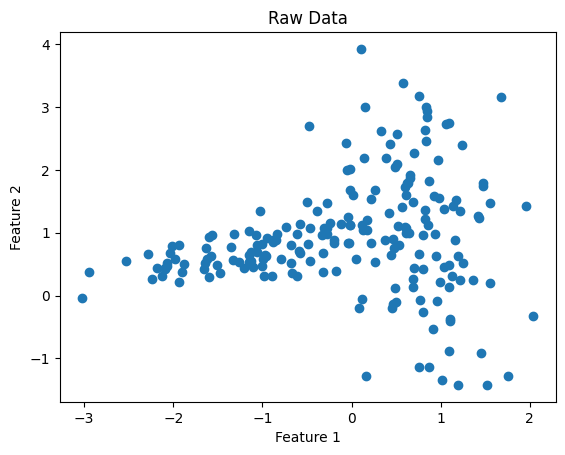

In [7]:
Xc_2, _ = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=0,
    n_clusters_per_class=1,
    class_sep=0.8
)

plt.figure()
plt.scatter(Xc_2[:, 0], Xc_2[:, 1])
plt.title('Raw Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
def initialize_centroids(X, K):
    indices = np.random.choice(len(X), size=K, replace=False)
    return X[indices].copy()

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, K):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])

def compute_cost(X, labels, centroids):
    assigned = centroids[labels]
    distances_sq = np.sum((X - assigned) ** 2, axis=1)
    return distances_sq.mean()

def run_kmeans(X, K, max_iters=300):

    centroids = initialize_centroids(X, K)
    cost_history = []

    for _ in range(max_iters):

        labels = assign_clusters(X, centroids)

        new_centroids = update_centroids(X, labels, K)

        cost = compute_cost(X, labels, new_centroids)
        cost_history.append(cost)

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return labels, centroids, cost, cost_history

def best_kmeans(X, K, n_runs=100):
    best_labels, best_centroids, best_cost, best_history = None, None, np.inf, []

    for _ in range(n_runs):
        labels, centroids, cost, history = run_kmeans(X, K)
        if cost < best_cost:
            best_labels, best_centroids, best_cost, best_history = labels, centroids, cost, history

    print(f"Best cost after {n_runs} runs {best_cost:.4f}")
    return best_labels, best_centroids, best_cost, best_history

In [9]:
K = 4
np.random.seed(42)

best_labels, best_centroids, best_cost, cost_history = best_kmeans(Xc_2, K=K, n_runs=100)

Best cost after 100 runs: 0.4577


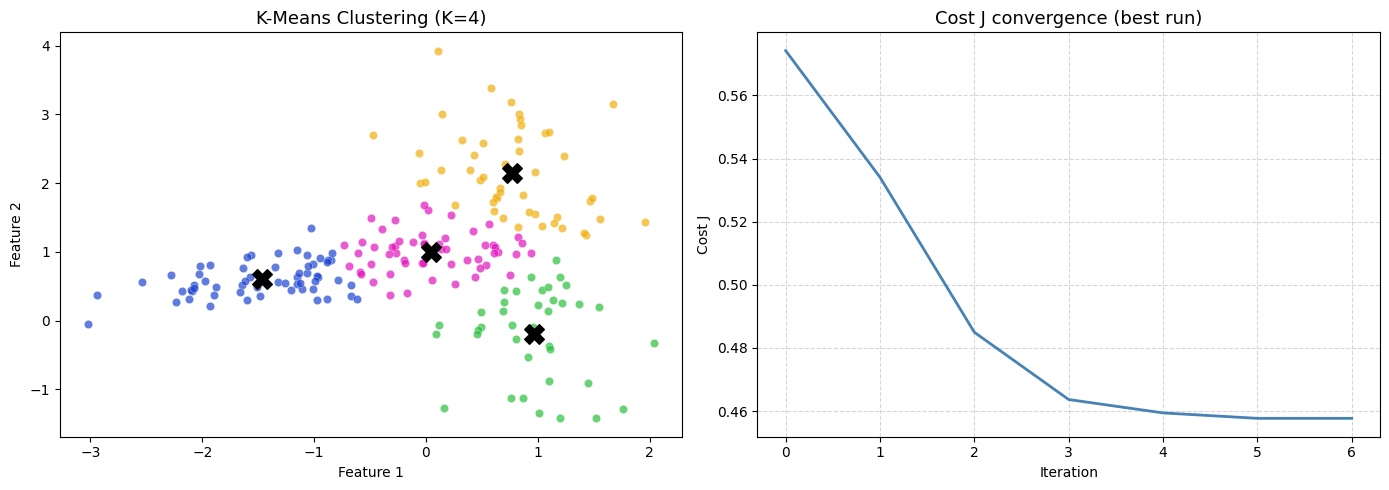

In [16]:
colors = ["#f0af0b", "#29c03d", "#1d44d2", "#e112bb"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for k in range(K):
    mask = best_labels == k
    ax.scatter(Xc_2[mask, 0], Xc_2[mask, 1],
               c=colors[k], label=f'Cluster {k}', alpha=0.7, edgecolors='white', linewidths=0.3)
ax.scatter(best_centroids[:, 0], best_centroids[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')
ax.set_title(f'K-Means Clustering (K={K})', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

ax2 = axes[1]
ax2.plot(cost_history, color='steelblue', linewidth=2)
ax2.set_title('Cost J convergence (best run)', fontsize=13)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost J')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()